In [201]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
from sklearn.model_selection import cross_val_score

## Data Overview

In [202]:
data = pd.read_csv("garments_worker_productivity.csv", parse_dates=["date"])
data.sample(5)

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
960,2015-02-26,Quarter4,finishing,Thursday,9,0.75,2.90,NaN,960,0,0.0,0,0,8.0,0.407813
527,2015-01-31,Quarter5,finishing,Saturday,5,0.70,3.94,NaN,240,0,0.0,0,0,2.0,0.971867
52,2015-01-04,Quarter1,finishing,Sunday,2,0.80,3.94,NaN,960,0,0.0,0,0,8.0,0.792104
434,2015-01-25,Quarter4,sweing,Sunday,11,0.75,42.97,532.0,10260,40,0.0,0,0,57.0,0.591142
491,2015-01-28,Quarter4,finishing,Wednesday,8,0.65,4.15,NaN,960,0,0.0,0,0,8.0,0.553333


In [203]:
# Shape
data.shape

(1197, 15)

In [204]:
# Check for missing values
data.isnull().sum()

date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

In [205]:
# Summary stats
data.describe()

,date,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,2015-02-04 10:56:50.526315776,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
min,2015-01-01 00:00:00,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,2015-01-18 00:00:00,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,2015-02-03 00:00:00,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,2015-02-23 00:00:00,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,2015-03-11 00:00:00,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437
std,NaN,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488


In [206]:
# Data types of the columns
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   1197 non-null   datetime64[ns]
 1   quarter                1197 non-null   object        
 2   department             1197 non-null   object        
 3   day                    1197 non-null   object        
 4   team                   1197 non-null   int64         
 5   targeted_productivity  1197 non-null   float64       
 6   smv                    1197 non-null   float64       
 7   wip                    691 non-null    float64       
 8   over_time              1197 non-null   int64         
 9   incentive              1197 non-null   int64         
 10  idle_time              1197 non-null   float64       
 11  idle_men               1197 non-null   int64         
 12  no_of_style_change     1197 non-null   int64         
 13  no_

### Checking for Categorical values consistency and typos

In [207]:
# Quarter - Move the values of quarter 5 into quarter 4
data["quarter"].value_counts()

quarter
Quarter1    360
Quarter2    335
Quarter4    248
Quarter3    210
Quarter5     44
Name: count, dtype: int64

In [208]:
data.replace("Quarter5", "Quarter4", inplace=True)

In [209]:
data["quarter"].value_counts()

quarter
Quarter1    360
Quarter2    335
Quarter4    292
Quarter3    210
Name: count, dtype: int64

In [210]:
# Department  -> "sweing" --> "sewing", "finishing " --> "finishing"
data["department"].unique()

array(['sweing', 'finishing ', 'finishing'], dtype=object)

In [211]:
# Day
data["day"].unique()

array(['Thursday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday'],
      dtype=object)

In [212]:
# team
data["team"].value_counts().sort_index()

team
1     105
2     109
3      95
4     105
5      93
6      94
7      96
8     109
9     104
10    100
11     88
12     99
Name: count, dtype: int64

In [213]:
# Correcting the department values
data.replace({"sweing": "sewing", "finishing ": "finishing"}, inplace=True)

In [214]:
data["department"].unique()

array(['sewing', 'finishing'], dtype=object)

### Drop columns

In [215]:
# Drop wip column
data = data.drop(columns=["wip"])

In [216]:
# Drop date column
data = data.drop(columns=["date"])

In [217]:
# Dropping idle_team, idle_men
data = data.drop(columns=["idle_men", "idle_time"])

In [218]:
data.shape

(1197, 11)

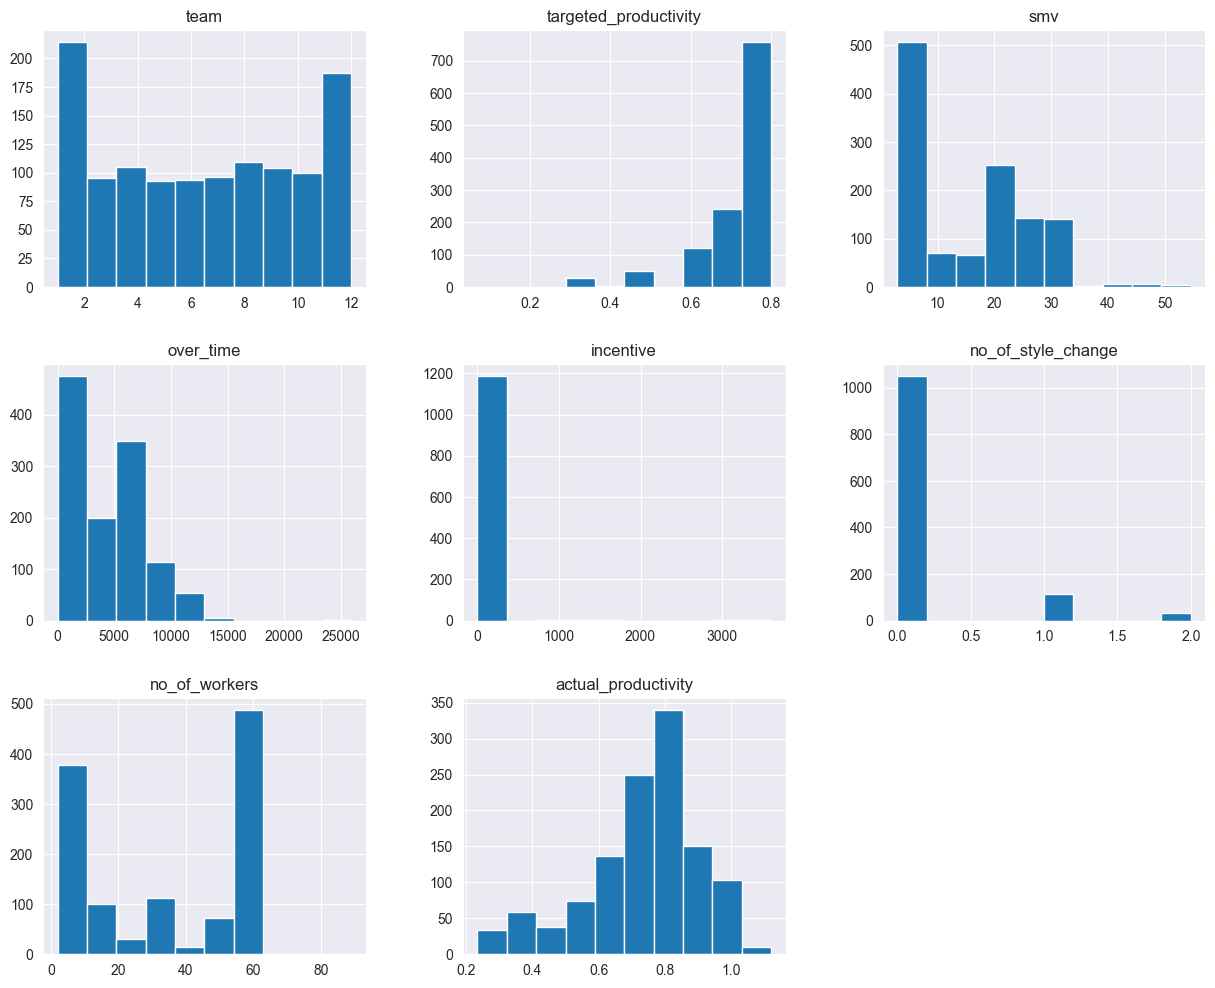

In [219]:
data.hist(figsize=(15, 12))
plt.show()

## Data Cleaning

In [220]:
data.sample(3)

,quarter,department,day,team,targeted_productivity,smv,over_time,incentive,no_of_style_change,no_of_workers,actual_productivity
597,Quarter1,finishing,Tuesday,6,0.7,2.90,960,0,0,8.0,0.495417
306,Quarter3,sewing,Sunday,4,0.7,22.52,10170,50,0,56.5,0.700542
1009,Quarter1,sewing,Monday,12,0.8,15.26,4080,63,0,34.0,0.800402


In [221]:
data.replace({"Quarter1": 1, "Quarter2": 2, "Quarter3": 3, "Quarter4": 4}, inplace=True)

C:\Users\muham\AppData\Local\Temp\ipykernel_15704\331526543.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({"Quarter1": 1, "Quarter2": 2, "Quarter3": 3, "Quarter4": 4}, inplace=True)


In [222]:
data.sample(3)

,quarter,department,day,team,targeted_productivity,smv,over_time,incentive,no_of_style_change,no_of_workers,actual_productivity
1062,1,finishing,Wednesday,7,0.8,4.60,8400,0,0,20.0,0.684889
388,4,sewing,Thursday,8,0.8,40.99,10770,30,0,56.5,0.555500
1153,2,finishing,Tuesday,3,0.8,4.60,1440,0,0,12.0,0.894444


In [223]:
# Making no_of_worker integer
data["no_of_workers"] = data["no_of_workers"].astype("int")

In [224]:
# Actual productivity should feature values to two decimal places
data["actual_productivity"] = data["actual_productivity"].round(2)

In [225]:
data.head()

,quarter,department,day,team,targeted_productivity,smv,over_time,incentive,no_of_style_change,no_of_workers,actual_productivity
0,1,sewing,Thursday,8,0.80,26.16,7080,98,0,59,0.94
1,1,finishing,Thursday,1,0.75,3.94,960,0,0,8,0.89
2,1,sewing,Thursday,11,0.80,11.41,3660,50,0,30,0.80
3,1,sewing,Thursday,12,0.80,11.41,3660,50,0,30,0.80
4,1,sewing,Thursday,6,0.80,25.90,1920,50,0,56,0.80


In [226]:
# Setting new column for classifier based on whether productivity was reached or not
data["productive"] = (data["actual_productivity"] >= data["targeted_productivity"])

In [227]:
data.sample(2)

,quarter,department,day,team,targeted_productivity,smv,over_time,incentive,no_of_style_change,no_of_workers,actual_productivity,productive
255,2,sewing,Wednesday,11,0.35,14.61,7200,23,0,55,0.35,True
1182,2,finishing,Wednesday,5,0.70,3.94,1440,0,0,12,0.76,True


## Machine learning Data Prep

In [228]:
# Convert department column to boolean
# Change the name of the column to is_sewing
data.rename(columns={"department": "is_sewing"}, inplace=True)
# If the value is sewing, set it to 1, otherwise 0
data["is_sewing"] = data["is_sewing"].map({"sewing": 1, "finishing": 0}).astype("int64")

In [229]:
data.sample(3)

,quarter,is_sewing,day,team,targeted_productivity,smv,over_time,incentive,no_of_style_change,no_of_workers,actual_productivity,productive
430,4,1,Sunday,12,0.7,15.26,6120,40,0,34,0.70,True
902,4,0,Monday,7,0.7,5.13,960,0,0,8,0.36,False
945,4,1,Thursday,7,0.8,30.10,4080,50,1,59,0.80,True


In [230]:
# Converting the quarter column into dummy variables
data = pd.get_dummies(data, columns=["quarter"], prefix="q")
data.sample(4)

,is_sewing,day,team,targeted_productivity,smv,over_time,incentive,no_of_style_change,no_of_workers,actual_productivity,productive,q_1,q_2,q_3,q_4
805,0,Tuesday,7,0.70,5.13,1200,0,0,10,0.91,True,False,False,True,False
1177,0,Wednesday,1,0.75,3.94,1920,0,0,8,0.81,True,False,True,False,False
462,0,Tuesday,3,0.75,3.94,1440,0,0,12,0.86,True,False,False,False,True
1019,1,Monday,5,0.65,27.48,6720,34,0,56,0.70,True,True,False,False,False


In [231]:
# Converting day variable into get_dummies
data = pd.get_dummies(data, columns=["day"], prefix="is")

In [232]:
data.sample(4)

,is_sewing,team,targeted_productivity,smv,over_time,incentive,no_of_style_change,no_of_workers,actual_productivity,productive,q_1,q_2,q_3,q_4,is_Monday,is_Saturday,is_Sunday,is_Thursday,is_Tuesday,is_Wednesday
621,0,2,0.80,3.94,2640,0,0,22,1.00,True,True,False,False,False,False,False,False,True,False,False
746,1,8,0.65,30.10,7080,0,1,59,0.46,False,False,True,False,False,False,False,False,True,False,False
376,1,10,0.75,22.52,10080,55,0,56,0.80,True,False,False,False,True,False,False,False,True,False,False
821,1,2,0.50,30.33,6720,0,1,56,0.36,False,False,False,True,False,False,False,False,False,True,False


In [233]:
# Converting the team into get_dummies
data = pd.get_dummies(data, columns=["team"], prefix="team")

In [234]:
pd.set_option("display.max_columns", None)

In [235]:
data.sample(4)

,is_sewing,targeted_productivity,smv,over_time,incentive,no_of_style_change,no_of_workers,actual_productivity,productive,q_1,q_2,q_3,q_4,is_Monday,is_Saturday,is_Sunday,is_Thursday,is_Tuesday,is_Wednesday,team_1,team_2,team_3,team_4,team_5,team_6,team_7,team_8,team_9,team_10,team_11,team_12
802,0,0.7,4.15,1800,0,0,15,0.26,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
768,1,0.8,22.52,6840,113,0,57,1.00,True,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
503,0,0.5,2.90,1200,0,0,10,0.90,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False
954,1,0.7,30.33,6960,0,1,58,0.66,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False


## Build the Decision Tree

In [236]:
# Separate the Data
X = data.drop(columns=["actual_productivity", "productive"], axis=1)
y = data["productive"]

In [237]:
X.shape

(1197, 29)

In [238]:
y.shape

(1197,)

In [239]:
# Split the data into train, test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=0)

In [240]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(897, 29) (300, 29)
(897,) (300,)


In [241]:
tree = DecisionTreeClassifier(max_depth=3, random_state=0)
tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

In [242]:
y_predict = tree.predict(X_test)

## Visualizing the model

In [243]:
print(f"Accuracy: {accuracy_score(y_test, y_predict)}")

Accuracy: 0.78


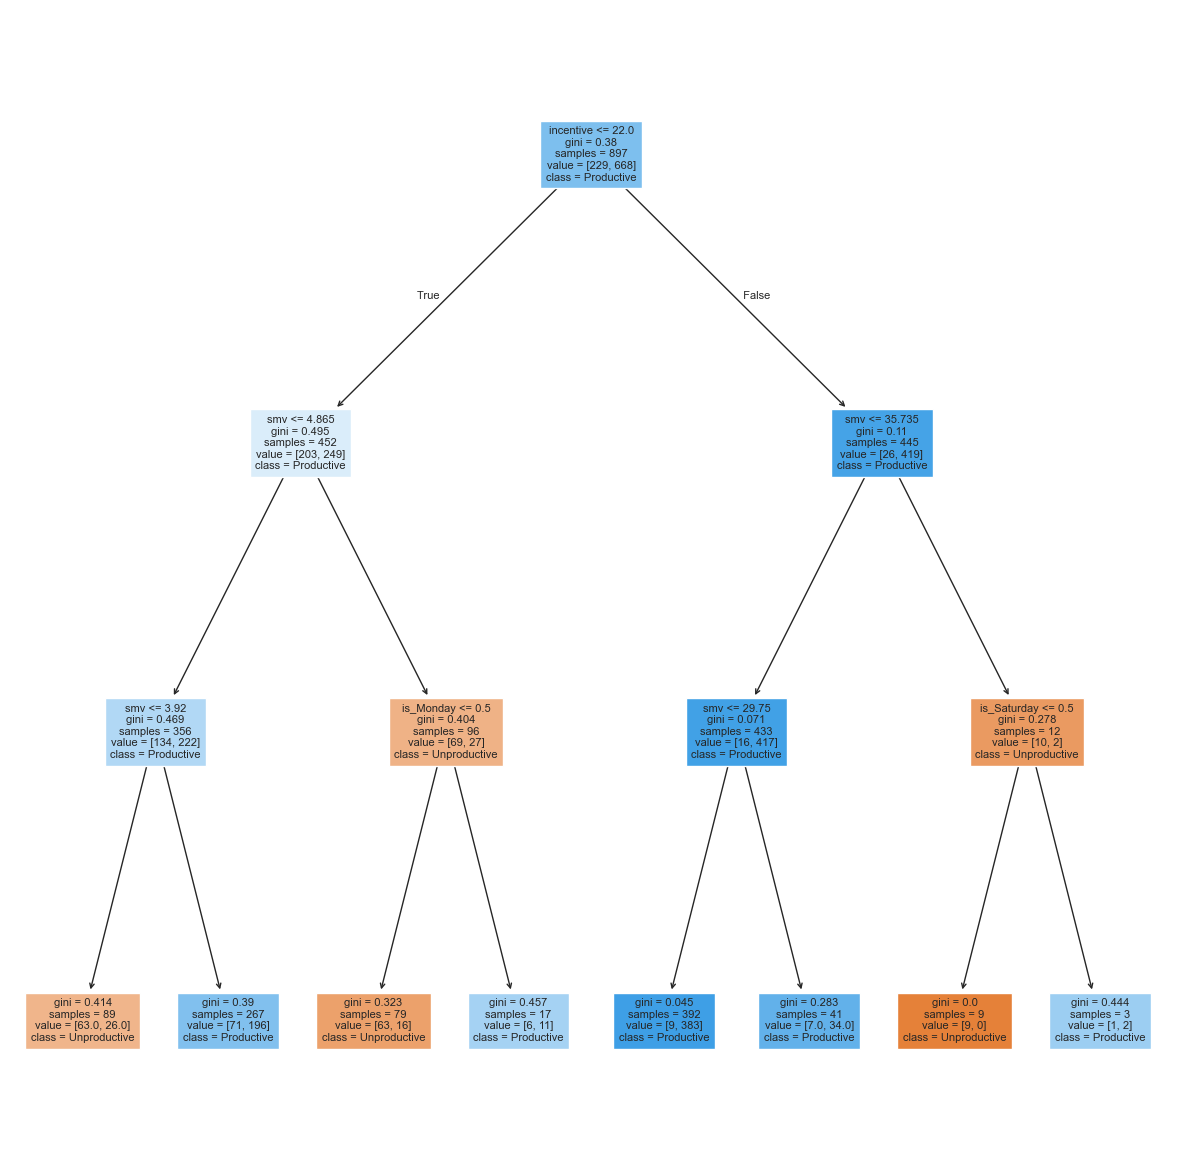

In [244]:
plt.figure(figsize=(15, 15))
plot_tree(tree, feature_names=X.columns, class_names=["Unproductive", "Productive"], filled=True, fontsize=8)
plt.show()

## Evaluating the Model

In [245]:
confusion_matrix(y_test, y_predict)

array([[ 38,  35],
       [ 31, 196]])

In [246]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", round(precision_score(y_test, y_predict), 2))
print("Recall:", round(recall_score(y_test, y_predict), 2))
print("F1 Score:", round(f1_score(y_test, y_predict), 2))
print("----")
print("Accuracy:", round(tree.score(X_test, y_test), 2))

Precision: 0.85
Recall: 0.86
F1 Score: 0.86
----
Accuracy: 0.78


In [247]:
scores = cross_val_score(tree, X, y, cv=8)

In [248]:
print(scores)

[0.86       0.68666667 0.84       0.86666667 0.82666667 0.74496644
 0.83221477 0.7852349 ]


In [249]:
print(f"Cross Validation Accuracy Scores: {scores}")
print(f"Average Cross validation Score: {round(scores.mean(), 2)}")

Cross Validation Accuracy Scores: [0.86       0.68666667 0.84       0.86666667 0.82666667 0.74496644
 0.83221477 0.7852349 ]
Average Cross validation Score: 0.81


In [250]:
from sklearn.model_selection import cross_validate

multiple_cross_scores = cross_validate(
                             tree,
                             X, y, cv=10,
                             scoring= ("precision", "recall", "f1") )

print("Mean Cross Validated Precision:", round(multiple_cross_scores["test_precision"].mean(), 2))
print("Mean Cross Validated recall:", round(multiple_cross_scores["test_recall"].mean(), 2))
print("Mean Cross Validated F1:", round(multiple_cross_scores["test_f1"].mean(), 2))

Mean Cross Validated Precision: 0.85
Mean Cross Validated recall: 0.92
Mean Cross Validated F1: 0.88
